# Νευρωνικά Δίκτυα: Εκπαίδευση

Σε αυτό το Notebook συνεχίζουμε την μελέτη των νευρωνικών δικτύων με την Pytorch.

Θα μάθουμε πως να χτίζουμε νευρωνικά δίκτυα με πολλαπλά επίπεδα, και με μη-γραμμικές συναρτήσεις, και σηναντικότερο ακόμα, θα μάθουμε να εκπαιδεύουμε νευρωνικά δίκτυα: θα μάθουμε πως γίνεται το ``model.fit``. Για να το κάνουμε αυτό θα χρειαστεί επίσης να μάθουμε πως να προσαρμώσουμε τα δεδομένα μας για τα χρησιμοποιούν οι μεθόδους που περιέχει η βιβλιοθήκη της Pytorch.

Πιο συγκεκριμένα:

1. Θα μάθουμε τι είναι και πως χρησιμοποιούμε τα Data Loaders.
2. Θα φτιάξουμε ένα απλό νευρωνικό δίκτυο με μόνο ένα επίπεδο χωρίς ReLU, και θα το εκπαιδεύσουμε.
5. Θα χτίσουμε ένα νευρωνικό δίκτυο με 2 επίπεδα και με ReLU, και θα το εκπαιδεύσουμε.
4. Θα δούμε πως τα πιο βαθιά δίκτυα με ReLU έχουμε μή-γραμμικές ισοϋψείς καμπύλες.


```
Κωνσταντίνος Καραμανής: constantine@utexas.edu
http://users.ece.utexas.edu/~cmcaram/
The University of Texas at Austin
Archimedes/Athena RC
```

## Βασικές Ιδέες

Θέλουμε να τονίσουμε τις παρακάτω βασικές ιδέες:

1. Όταν μάθαμε τον πρώτο μας αλγόριθμο -- τα δέντρα απόφασης -- μάθαμε και την εντολή

```
model = DecisionTreeClassifier(max_depth = 3)
```
Αυτή η εντολή μας λέει πως θα ψάξουμε όλα τα δέντρα με βάθος το πολύ τρία, για να βρούμε το δέντρο που έχει την μέγιστη ακρίβεια πάνω στα δεδομένα μας.

Μετά δίνουμε την εντολή
```
model.fit(X,y)
```
Αυτή είναι η εντολή που βρίσκει αυτό το "καλύτερο" δέντρο.

2. Πρέπει να δούμε τι θα αντικαταστήσει αυτές τις δύο εντολές.

* Η πρώτη εντολή είναι η ίδια:
```
model = NeuralNet_WeDesign()
```
αλλά όπως λέει και το όνομα, **εμείς** θα σχεδιάσουμε την οικογένεια NeuralNet_WeDesign(), ορίζοντας πόσα επίπεδα έχει, και πόσους νευρώνες περιέχει κάθε επίπεδο. Αυτό το είδαμε και [στο προηγούμενο Notebook](https://colab.research.google.com/drive/1EVNEGakrtSQTHcUdO_lYJPSIPMHEjJZb?usp=sharing).

* Η δεύτερη εντολή έχει πιο περίπλοκη αντικατάσταση. Όταν παίζαμε με δέντρα απόφασης, ήταν σχετικά εύκολο να βρούμε το βέλτιστο δέντρο βάθους 1. Δεν είναι έτσι απλά τα πράγματα με τα νευρωνικά δίκτυα. Υπάρχουν πάρα πολλές παράμετροι, και δεν είναι εύκολο να βρεθούν παράμετροι που δίνουν καλή ακρίβεια (μικρό σφάλμα/λάθος). Οπότε αντί απλά για μία έντολη σαν το model.fit(X,y), θα εκπαιδεύσουμε το νευρωνικό και μία εντολή που έχει την μορφή:
```
train(model,data,optimizer,epochs)
```
που σημαίνει: Να ψάξεις για καλές παραμέτρους χρησιμοποιώντας τη στρατηγική που περιγράφει ο "optimizer" και να συνεχίσεις να ψάχνεις κοιτώντας ένα ένα τα δεδομένα "epoch" φορές.

Για να μπούμε σε όλες τις λεπτομέρειες του τί ακριβώς κάνει ο "optimizer" απαιτεί συζήτηση για Gradient Descent. Οπότε αυτές τις μαθηματικές λεπτομέρειες τις αφήνουμε για άλλη φορά, και άλλη διάλεξη.

Θα εξερευνήσουμε το ζήτημα με εμπειρικό τρόπο στο τελευταίο κομμάτι του Notebook.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F



## Δημιουργούμε δεδομένα

Χρησιμοποιούμε τον ίδιο κώδικα που είδαμε στο προηγούμενο Notebook.

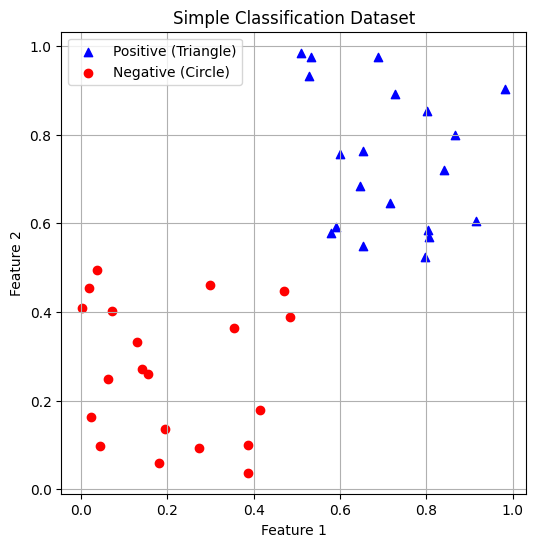

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Seed for reproducibility
np.random.seed(42)

# Generate positive examples in the upper right quadrant
X_positive = np.random.uniform(0.5,1.0,(20,2))

# Generate negative examples in the lower left quadrant
X_negative = np.random.uniform(0.0, 0.5,(20,2))

# Plotting the data
plt.figure(figsize=(6, 6))
plt.scatter(X_positive[:,0],X_positive[:,1], marker='^', color='blue', label='Positive (Triangle)')
plt.scatter(X_negative[:,0],X_negative[:,1], marker='o', color='red', label='Negative (Circle)')
plt.title('Simple Classification Dataset')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()


## Η Οικογένεια Νευρωνικών Δικτύων

Φτιάχνουμε την πιο απλή οικογένεια νευρωνικών δικτύων, με ένα μόνο επίπεδο, και με softmax.

Το νευρωνικό δίκτυο προσπαθεί να προβλέψει την ταξινόμηση. To output του μοντέλου μας είναι οι πιθανότητες με τις οποίες πιστεύει πως το input ανήκει σε κάθε κατηγορία.

Για παράδειγμα, εάν μας πεί $(0,85, 0,15)$, τότε σημαίνει πως το νευρωνικό δίκτυο πιστεύει πως *μάλλον* ανήκει στην πρώτη κατηγορία (85%), αλλά μπορεί (15%) να ανήκει στην δεύτερη κατηγορία.

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SimpleClassifier(nn.Module):
    def __init__(self):
        super(SimpleClassifier, self).__init__()
        self.fc = nn.Linear(2, 2)  # Input dimension is 2, output dimension is 2 (one for each class)

    def forward(self, x):
        x = self.fc(x)
        x = F.softmax(x,dim=1)
        return x


## Ένα Νευρωνικό Δίκτυο

Από την οικογένεια που ορίσαμε, επιλέγουμε ένα συγκεκριμένο.

Αυτό σημαίνει πως ορίζουμε τιμές για τις παραμέτρους του μοντέλου.

Προσοχή: δεν δώσαμε εντολή ανάλογη με το model.fit(X,y) -- το συγκεκριμένο δίκτυο το επιλέξαμε εμείς, δεν το επέλεξε ο υπολογιστής ώστε να έχει μέχιστη ακρίβεια στα δεδομένα $(X,y)$.

In [4]:
model = SimpleClassifier()
# Set weights and biases
model.fc.weight = nn.Parameter(torch.tensor([[-1.0, 1.0], [1.0, -1.0]]))
model.fc.bias = nn.Parameter(torch.tensor([-0.0, 0.0]))


## Πως τα πάει;

Να δούμε τώρα τι κάνει αυτό το νευρωνικό δίκτυο που ορίσαμε.
Θα διαλέξουμε τρία από τα δεδομένα που βλέπουμε απεικονισμένα στην εικόνα παραπάνω:

1. Το σημείο $(0.1,0.15)$ στην κάτω αριστερή γωνία.
2. Το σημείο $(0.8,0.8)$ στην πάνω δεξιά γωνία.
3. Το σημείο $(0.5,0.45)$ που είναι κάπου στην μέση.

**Ερώτηση**: Τι περιμένουμε σαν απαντήσεις από ένα "καλό" νευρωνικό δίκτυο; Εσείς τι θα δίνατε σαν απάντηση;

In [5]:
# Select a few examples
points = torch.tensor([[0.1, 0.15],[0.8,0.8],[0.5,0.45]], dtype=torch.float32)

# Feed them through the network
outputs = model(points)

print("Outputs for selected points:\n", outputs)


Outputs for selected points:
 tensor([[0.5250, 0.4750],
        [0.5000, 0.5000],
        [0.4750, 0.5250]], grad_fn=<SoftmaxBackward0>)


## Τα πήγε καλά;

Βλέπουμε πως το νευρωνικό που διαλέξαμε -- δηλαδή το νευρωνικό δίκτυο που αντιστοιχεί στις παραμέτρους που διαλέξαμε, φαίνεται να μήν συμφωνεί διαισθητικά με την εικόνα:

1. Το σημείο $(0.1,0.15)$ στην κάτω αριστερή γωνία: 52.5% κόκκινο
2. Το σημείο $(0.8,0.8)$ στην πάνω δεξιά γωνία: 50% κόκκινο
3. Το σημείο $(0.5,0.45)$ που είναι κάπου στην μέση: 47.5% κόκκινο

Δηλαδή και τα τρία αυτά σημεία τα βλέπει περίπου ίδια. Δεν ταιριάζει αυτό με την διαίσθηση μας.

Ας δούμε τις "ισοϋψείς καμπύλες" για να καταλάβουμε καλύτερα πως λειτουργεί το νευρωνικό δίκτυο.

In [6]:
# Function to plot decision boundaries
def plot_decision_boundary(model, X, y):

    # make a fine mesh grid of points and label them with model
    x_min, x_max = X[:,0].min(), X[:,0].max()
    y_min, y_max = X[:,1].min(), X[:,1].max()
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
    grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)
    with torch.no_grad():
        probs = model(grid)
        Z = probs[:, 0] - probs[:, 1]
        Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, cmap="RdBu", alpha=0.5)

    # Now plot the original points, along with their true label given in y
    # Extract positive and negative indices based on y
    positive_indices = np.where(y == 1)[0]
    negative_indices = np.where(y == 0)[0]

    # Split X into positive and negative components
    X_positive = X[positive_indices, :]
    X_negative = X[negative_indices, :]
    plt.scatter(X_positive[:,0], X_positive[:,1], marker='^', color='red', label='Positive (Triangle)')
    plt.scatter(X_negative[:,0], X_negative[:,1], marker='o', color='blue', label='Negative (Circle)')
    plt.title("Decision Region with Data Points")
    plt.show()

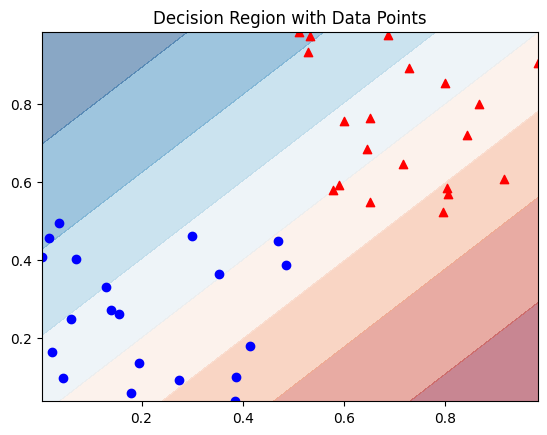

In [7]:
X = np.vstack((X_positive,X_negative))
y = np.array([1]*20 + [0]*20)  # Correctly assigning labels to each class

plot_decision_boundary(model, X, y)

## Δεν βρήκαμε καλό δίκτυο

Οι τιμές που δώσαμε για τις παράμετρους του δικτύου δεν είναι καλές: το νευρωνικό δίκτυο που ορίζουν δεν ταξινομεί σωστά τα δεδομένα μας.

Για αυτό το απλό δίκτυο, μπρούμε φυσικά να ψάξουμε μόνοι μας και να βρούμε παράμετρους που ταξινομούν σωστά (όπως και κάναμε στο [προηγούμενο Notebook](https://colab.research.google.com/drive/1EVNEGakrtSQTHcUdO_lYJPSIPMHEjJZb?usp=sharing)).

Για πιο περίπλοκα δίκτυα με πολλές παραμέτρους, αυτό δεν γίνεται. Χρειαζόμαστε αυτόματο (αλγοριθμικό) τρόπο να βρίσκουμε καλές παραμέτρους. Πρέπει να μάθουμε να εκπαιδεύουμε νευρωνικά δίκτυα, δηλαδή, την αντίστοιχη εντολή με το ``model.fit(X,y)``.

# Εκπαίδευση Νευρωνικών

1. Data Loader
2. GPU
3. Εκπαίδευση: train(model, train_loader, optimizer, epochs)


### Data Loader

Στις μοντέρνες εφαρμογές, τα νευρωνικά δίκτυα συνήθως χρησιμοποιούνται σε σετ δεδομένων τεράστιου μεγέθους. Αυτά χρειάζονται προσεκτική μεταχείριση. Εμάς δεν μας αφορά άμεσα, μιά που όλα τα παραδείγματα που θα δούμε χωράνε την μνήμη (RAM) του επεξεργαστή που μας δείνει το Colab.

Αλλά επειδή έτσι λειτουργεί η PyTorch, πρέπει να χρησιμοποιήσουμε τα Data Loaders για τα δεδομένα μας.

Μπορούμε απλά να το σκεφτούμε σαν "black box" προς το παρόν.

Αλλιώς, δείτε εδώ:

* Τutorial: https://pytorch.org/tutorials/beginner/basics/data_tutorial.html

* https://towardsdatascience.com/beginners-guide-to-loading-image-data-with-pytorch-289c60b7afec
* https://stackoverflow.com/questions/51756581/how-do-i-turn-a-pytorch-dataloader-into-a-numpy-array-to-display-image-data-with

* https://pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html

Για τις δικές μας ανάγκες προς το παρόν, αρκεί να ξέρουμε πως τα δεδομένα πρέπει να τα διαμορφώσουμε με ειδικό τρόπο, σε κάτι που λέγεται "**Data Loader**". Και αρκεί να ξέρουμε πως πρέπει να χρησιμοποιήσουμε κώδικα όπως εδώ, για να φτιάξουμε αυτά τα "Data Loaders".

In [8]:
from torch.utils.data import TensorDataset, DataLoader
import torch

# τα δεδομένα (X,y) τα έχουμε δημιουργήσει πιο πάνω
tensor_x_train = torch.tensor(X, dtype=torch.float32) # transform to torch tensor
tensor_y_train = torch.tensor(y, dtype=torch.long)     # labels should be torch.long for classification

m = 32 # Batch size
data_train = TensorDataset(tensor_x_train, tensor_y_train) # create your dataset
train_loader = DataLoader(data_train, batch_size=m, shuffle=True) # create your dataloader with training data


### GPU

Εάν θέλουμε να χρησιμοποιήσουμε GPU, πρέπει:
1. Στο ``Runtime`` επιλέγουμε το ``Change runtime type``. Εμείς θα επιλλέξουμε το T4 GPU.
2. Πρέπει να πούμε του Collab να χρησιμοποιήσει GPU. Αυτό το κάνουμε με την παρακάτω εντολή.
```
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
```

In [11]:
# Set the device
#device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device = torch.device("mps")
device

device(type='mps')

In [12]:
print(torch.backends.mps.is_available())

True


In [17]:
import time
#Simple tensor operation to test MPS    
# CPU computation
print("Testing CPU computation...")
device_cpu = torch.device("cpu")
# Start timer
start_time = time.perf_counter()
x_cpu = torch.rand((100000, 100000), device=device_cpu)
print(x_cpu)
y_cpu = x_cpu * x_cpu
print("CPU computation completed.")
# End timer
end_time = time.perf_counter()
# Calculate elapsed time
elapsed_time = end_time - start_time
print(f"Execution time: {elapsed_time:.6f} seconds")
# MPS computation
print("Testing MPS computation...")
device_mps = torch.device("mps")
# Start timer
start_time = time.perf_counter()
x_mps = torch.rand((100000, 100000), device=device_mps)
print(x_mps)
y_mps = x_mps * x_mps
print("MPS computation completed.")
# End timer
end_time = time.perf_counter()
# Calculate elapsed time
elapsed_time = end_time - start_time
print(f"Execution time: {elapsed_time:.6f} seconds")

Testing CPU computation...
tensor([[0.6730, 0.2608, 0.2495,  ..., 0.1940, 0.3955, 0.7094],
        [0.0257, 0.9781, 0.5933,  ..., 0.9288, 0.1311, 0.2216],
        [0.3666, 0.1316, 0.3604,  ..., 0.5400, 0.9722, 0.5269],
        ...,
        [0.8976, 0.3509, 0.5450,  ..., 0.4673, 0.9997, 0.2345],
        [0.3983, 0.6592, 0.8124,  ..., 0.5126, 0.6970, 0.3820],
        [0.9575, 0.6129, 0.8206,  ..., 0.7886, 0.2326, 0.0764]])
CPU computation completed.
Execution time: 22.233446 seconds
Testing MPS computation...
tensor([[0.5420, 0.2279, 0.2441,  ..., 0.4529, 0.8977, 0.6414],
        [0.9823, 0.0503, 0.3918,  ..., 0.2945, 0.0622, 0.1598],
        [0.5229, 0.9405, 0.7164,  ..., 0.9491, 0.5452, 0.3804],
        ...,
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]],
       device='mps:0')
MPS computation completed.
Execution time: 21.110602 seconds


## Εκπαίδευση / Training

Όπως έχουμε εξηγήσει, η εκπαίδευση είναι πλέον πιο δύσκολη/σύνθετη διαδικασία.

Αντί για το απλό ```model.fit(X,y)``` χρειαζόμαστε μία διαδικασία που λέει πώς θα ψάξουμε για *αρκετά καλές* παραμέτρους, και πόσο θα ψάξουμε.

Ο παρακάτω κώδικας το κάνει αυτό:

```
train(model, train_loader, optimizer, epochs)
```
Το

```model```

είναι το μοντέλο μας, το

```train_loader```

είναι τα δεδομένα, δηλαδή το (X,y), το

```optimizer```

μας λέει πως θα ψάξουμε, και το

```epochs```

μας λέει πόσο χρόνο θα ψάξουμε -- συγκεκριμένα, πόσες φορές θα περάσουμε όλα τα δεδομένα μέχρι να βρούμε παραμέτρους που ταιριάζουν (αρκετά καλά).



### Τα βασικά βήματα της εκπαίδευσης

**Διαισθητικά**, ο παρακάτω κώδικας κάνει το εξής:
1. Ζητάει από τον Data Loader να του δώσει μερικά δείγματα από τα δεδομένα εκπαίδευσης.
2. Βλέπει τις τιμές ``y_pred`` που προβλέπει το μοντέλο με τις παραμέτρους που έχει.
3. Εκτιμάει το σφάλμα μεταξύ του ``y_pred`` και ``y``.
4. Ψάχνει για μικρές αλλαγές που μπορούν να γίνουν στις παραμέτρους του μοντέλου, για να μειωθεί το σφάλμα. Μετά αλλάζει τις παραμέτρους του μοντέλου προς την κατεύθυνση αυτής τις αλλαγής.
5. Επαναλαμβάνει αυτήν την διαδικασία ζητώντας καινούργια δεδομένα από τον Data Loader. Όταν εξαντλήσει τα δεδομένα (τα έχει δεί όλα μία φορά), έχει τελειώσει ένα ``epoch``. Σηνεχίζει για όσα epochs έχουμε ζητήσει.

### Κάποιες λεπτομέρειες για τον παρακάτω κώδικα
1. ``device``: αυτό λέει στο Colab να χρησιμοποιήσει GPU ή CPU για την εκπαίδευση. Όποτε μπορούμε, χρησιμοποιούμε GPU για νευρωνικά δίκτυα.
2. ``model.to(device)``, ``x.to(device)``, ``y.to(device)``: αυτές οι εντολές μετακινούν τα δεδομένα και τις παραμέτρους του μοντέλου στον επεξεργαστή που θα χρησιμοποιήσουμε.
3. ``criterion = nn.NLLLoss``: αυτό είναι το κριτήριο που χρησιμοποιείτε για τον υπολογισμού του σφάλματος (loss) μεταξύ του ``y_pred`` που προβλέπει το μοντέλο, και το ``y``. Το σφάλμα υπολογίζεται με την εντολή ``loss = criterion(outputs, y)``.
4. ``scheduler``: όταν βρεθεί μια κατεύθυνση που φαίνεται να βελτιώνει (μειώνει) το σφάλμα, παίρνουμε ένα βήμα προς αυτήν την κατεύθυνση. Το ``scheduler`` μας επιτρέπει να αλλάζουμε το μέγεθος του βήματος που παίρνουμε.

### Συνολικά, ο κώδικας:

1. Εκπαιδεύει το μοντέλο, προσπαθόντας να βρεί καλές παραμέτρους.
2. Αποθηκεύει το σφάλμα σε κάθε βήμα, και επίσης υπολογίζει την ακρίβεια σε κάθε βήμα. Σχετίζονται αυτά τα δύο (μικρότερο σφάλμα συνήθως αντιστοιχεί σε μεγαλύτερη ακρίβεια) αλλά η σχέση δεν είναι απόλυτη.
3. Δημιουργεί τα γραφήματα με τα σφάλματα και την ακρίβεια στα δεδομένα εκπαίδευσης.


In [85]:
from torch import optim
import torch
import copy
import torch.nn.functional as F
import matplotlib.pyplot as plt

def train(model, train_loader, optimizer, epochs):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    criterion = nn.NLLLoss()
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.1)
    train_losses = []
    train_accuracies = []  # List to store accuracy for each epoch
    best_accuracy = 0  # Best accuracy found
    best_model_wts = copy.deepcopy(model.state_dict())

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            outputs = model(x)
            loss = criterion(outputs, y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        scheduler.step()  # Update the learning rate

        train_losses.append(total_loss / len(train_loader))

        model.eval()
        total_train_loss = 0
        correct = 0
        total = 0
        with torch.no_grad():
            for x, y in train_loader:
                x, y = x.to(device), y.to(device)
                outputs = model(x)
                loss = criterion(outputs, y)
                total_train_loss += loss.item()

                _, predicted = torch.max(outputs.data, 1)
                total += y.size(0)
                correct += (predicted == y).sum().item()

        epoch_loss = total_train_loss / len(train_loader)
        epoch_accuracy = correct / total
        train_accuracies.append(epoch_accuracy)

        if epoch_accuracy > best_accuracy:
            best_accuracy = epoch_accuracy
            best_model_wts = copy.deepcopy(model.state_dict())
            best_epoch = epoch + 1

        print(f"Epoch {epoch+1}/{epochs}, Training Loss: {train_losses[-1]}, Training Accuracy: {epoch_accuracy:.4f}")

    # Load best model weights
    model.load_state_dict(best_model_wts)
    print(f"Loaded the best model from epoch {best_epoch} with Training Accuracy: {best_accuracy:.4f}")

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(range(1, epochs+1), train_losses, label='Training Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(range(1, epochs+1), train_accuracies, label='Training Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.show()

    return


In [86]:
# Set the random seed
torch.manual_seed(42)


In [87]:
model = SimpleClassifier()
model.to(device)


SimpleClassifier(
  (fc): Linear(in_features=2, out_features=2, bias=True)
)

In [88]:
optimizer = optim.Adam(model.parameters(), lr=0.1)
epochs = 2

## Δίνουμε την Εντολή "model.fit"

Επιτέλους είμασατε έτοιμοι να δώσουμε την εντολή *που αντιστοιχεί*, όπως έχουμε εξηγήσει, με την εντολή ```model.fit(X,y)```:
```
train(model,train_loader,optimizer,epochs)
```


Epoch 1/2, Training Loss: -0.46820661425590515, Training Accuracy: 0.5000
Epoch 2/2, Training Loss: -0.5043903142213821, Training Accuracy: 0.5000
Loaded the best model from epoch 1 with Training Accuracy: 0.5000


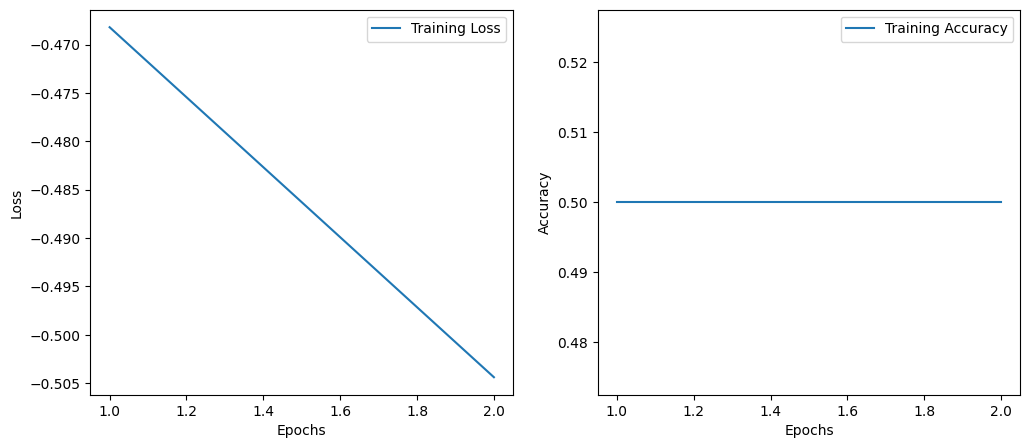

In [89]:
torch.manual_seed(42)
train(model, train_loader,optimizer, epochs)


## Πως τα πήγαμε;

Όπως βλέπουμε, **δεν τα πήγαμε πολύ καλά**.

Ας οπτικοποιήσουμε πάλι τις ισοϋψείς καμπύλες του (εκπαιδευμένου) μοντέλου μας.

Προσοχή: τα δεδομένα $X$ και $y$ είναι ακόμα στο CPU, ενώ το μοντέλο το στείλαμε στο ``device`` που είναι GPU εάν αλλάξαμε το runtime. Οπότε πρέπει να το ξαναβάλουμε στο CPU μαζί με τα $X$ και $y$ για να εκτελέσουμε την εντολή. Οπότε έχουμε:
```
plot_decision_boundary(model.to('cpu'), X, y)
```

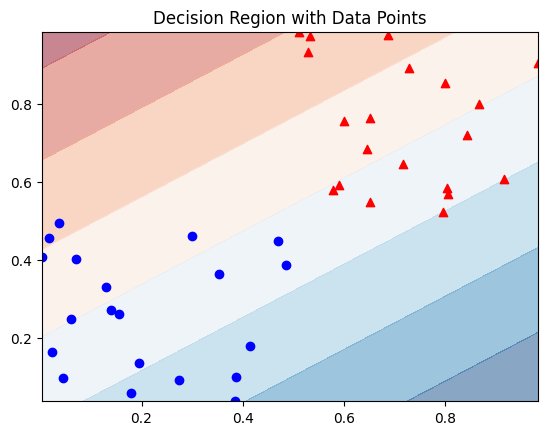

In [90]:
plot_decision_boundary(model.to('cpu'), X, y)

# Τί να Κάνουμε;

Μήπως να του δώσουμε ακόμα χρόνο να ψάξει;

Epoch 1/10, Training Loss: -0.527200847864151, Training Accuracy: 0.5000
Epoch 2/10, Training Loss: -0.539568305015564, Training Accuracy: 0.5000
Epoch 3/10, Training Loss: -0.5877042412757874, Training Accuracy: 0.5000
Epoch 4/10, Training Loss: -0.5805035829544067, Training Accuracy: 0.5000
Epoch 5/10, Training Loss: -0.606416255235672, Training Accuracy: 0.5750
Epoch 6/10, Training Loss: -0.6801874935626984, Training Accuracy: 0.6750
Epoch 7/10, Training Loss: -0.6600348949432373, Training Accuracy: 0.8000
Epoch 8/10, Training Loss: -0.6970192492008209, Training Accuracy: 0.9000
Epoch 9/10, Training Loss: -0.7314895689487457, Training Accuracy: 0.9250
Epoch 10/10, Training Loss: -0.768037885427475, Training Accuracy: 0.9500
Loaded the best model from epoch 10 with Training Accuracy: 0.9500


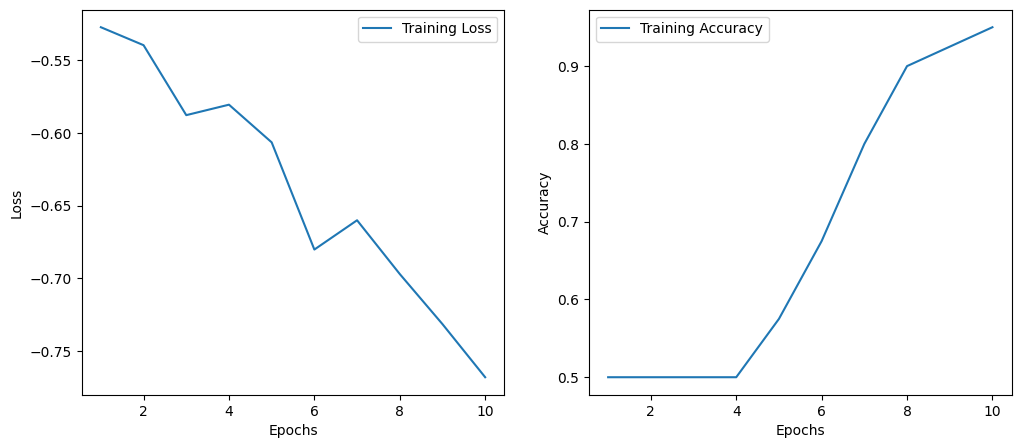

In [91]:
torch.manual_seed(42)
epochs = 10
train(model, train_loader, optimizer, epochs)


## Πως τα πήγαμε;

Όπως βλέπουμε, **τα πήγαμε πολύ καλύτερα**.

Καταφέραμε να βρούμε ένα μοντέλο (πάρα πολυ παρόμοιο με το δίκτυο που είχαμε ορίσει και μόνοι μας στο [προηγούμενο Notebook](https://colab.research.google.com/drive/1EVNEGakrtSQTHcUdO_lYJPSIPMHEjJZb?usp=sharing)) που έχει υψηλή ακρίβεια.

Μπράβο μας!

Ας πλοτάρουμε πάλι τις ισοϋψείς καμπύλες του (εκπαιδευμένου) μοντέλου μας.

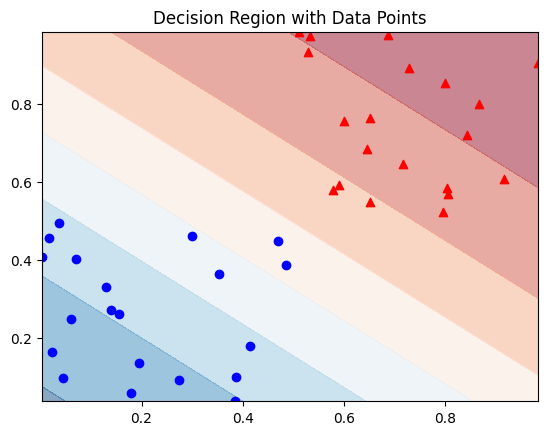

In [92]:
plot_decision_boundary(model.to('cpu'), X, y)

## Θα μπορούσαμε να το τρέξουμε ακόμα

Η ακρίβεια φαίνεται να συνεχίζει να ανεβαίνει. Οπότε αξίζει να το τρέξουμε ακόμα μερικά epochs να δούμε εάν θα συνεχίσει να βελτιώνεται.

Epoch 1/10, Training Loss: -0.7811651229858398, Training Accuracy: 0.9500
Epoch 2/10, Training Loss: -0.8021561503410339, Training Accuracy: 0.9750
Epoch 3/10, Training Loss: -0.8220002353191376, Training Accuracy: 0.9750
Epoch 4/10, Training Loss: -0.8207438290119171, Training Accuracy: 1.0000
Epoch 5/10, Training Loss: -0.8386915624141693, Training Accuracy: 1.0000
Epoch 6/10, Training Loss: -0.8624553978443146, Training Accuracy: 1.0000
Epoch 7/10, Training Loss: -0.853606641292572, Training Accuracy: 1.0000
Epoch 8/10, Training Loss: -0.8539887070655823, Training Accuracy: 0.9750
Epoch 9/10, Training Loss: -0.8680484294891357, Training Accuracy: 0.9750
Epoch 10/10, Training Loss: -0.8859524726867676, Training Accuracy: 0.9750
Loaded the best model from epoch 4 with Training Accuracy: 1.0000


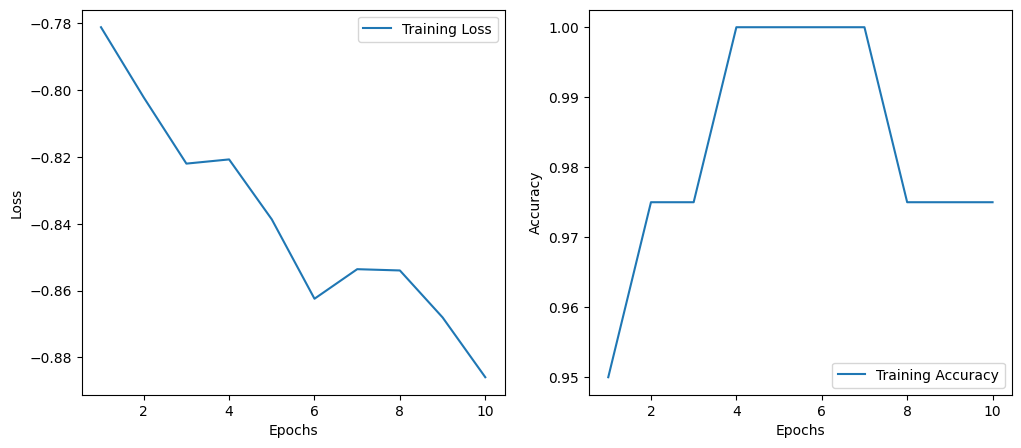

In [93]:
torch.manual_seed(42)
epochs = 10
train(model, train_loader,optimizer, epochs)

### Ποιές είναι οι παράμετροι που βρήκε;

Μπορούμε να ζητήσουμε τις τιμές των παραμέτρων που βρήκε η εκπαίδευση, με τις εντολές:
```
# Access the state dictionary
state_dict = model.state_dict()

# Get weights and biases of model.fc
fc_weights = state_dict['fc.weight']
fc_biases = state_dict['fc.bias']

# Print or use them
print(fc_weights)
print(fc_biases)
```

In [94]:
# Access the state dictionary
state_dict = model.state_dict()

# Get weights and biases of model.fc
fc_weights = state_dict['fc.weight']
fc_biases = state_dict['fc.bias']

# Print or use them
print(fc_weights)
print(fc_biases)

for key, value in model.state_dict().items():
    print(f"{key}: {value.shape}")

tensor([[-1.5061, -1.2682],
        [ 1.8810,  2.5047]])
tensor([ 1.6356, -1.6478])
fc.weight: torch.Size([2, 2])
fc.bias: torch.Size([2])


# Κάποιες Παρατηρήσεις

1. Τα πρώτα 5 περίπου epochs δεν είχε καταφέρει να βρεί καλές παραμέτρους -- κάπου είχε κολλήσει.
2. Αφού άρχισε να βελτιώνεται, πήρε ακόμα αρκετά epochs.
3. Εν τέλη, βρήκαμε πολύ καλή λύση.

# Δεύτερο Παράδειγμα

Τώρα θα δούμε ένα πιο περίπλοκο παράδειγμα που, όπως θα δούμε, απαιτεί βαθύτερο νευρωνικό δίκτυο για να πετύχει καλή (υψηλή) ακρίβεια.

In [95]:
import numpy as np
np.random.seed(42)
test = np.random.randn(5,2)*0.1+1
test
test2 = np.random.rand(100,2)
test2

array([[0.18182497, 0.18340451],
       [0.30424224, 0.52475643],
       [0.43194502, 0.29122914],
       [0.61185289, 0.13949386],
       [0.29214465, 0.36636184],
       [0.45606998, 0.78517596],
       [0.19967378, 0.51423444],
       [0.59241457, 0.04645041],
       [0.60754485, 0.17052412],
       [0.06505159, 0.94888554],
       [0.96563203, 0.80839735],
       [0.30461377, 0.09767211],
       [0.68423303, 0.44015249],
       [0.12203823, 0.49517691],
       [0.03438852, 0.9093204 ],
       [0.25877998, 0.66252228],
       [0.31171108, 0.52006802],
       [0.54671028, 0.18485446],
       [0.96958463, 0.77513282],
       [0.93949894, 0.89482735],
       [0.59789998, 0.92187424],
       [0.0884925 , 0.19598286],
       [0.04522729, 0.32533033],
       [0.38867729, 0.27134903],
       [0.82873751, 0.35675333],
       [0.28093451, 0.54269608],
       [0.14092422, 0.80219698],
       [0.07455064, 0.98688694],
       [0.77224477, 0.19871568],
       [0.00552212, 0.81546143],
       [0.

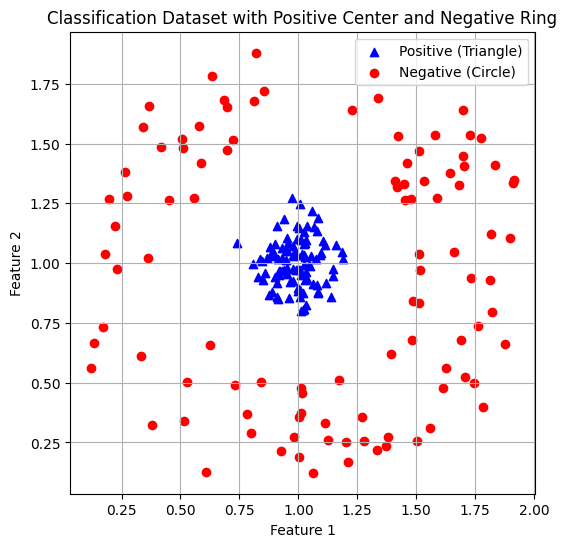

In [96]:
import numpy as np
import matplotlib.pyplot as plt

# Seed for reproducibility
np.random.seed(42)

# Generate positive examples centered around (1,1)
positive_x = 0.1 * np.random.randn(100, 2) + 1

# Generate negative examples in a ring-like structure
radius = 0.5 + 0.5 * np.random.rand(100, 1)
angle = 2 * np.pi * np.random.rand(100, 1)
negative_x = np.hstack((radius * np.cos(angle), radius * np.sin(angle))) + 1

# Plotting the data
plt.figure(figsize=(6, 6))
plt.scatter(positive_x[:, 0], positive_x[:, 1], marker='^', color='blue', label='Positive (Triangle)')
plt.scatter(negative_x[:, 0], negative_x[:, 1], marker='o', color='red', label='Negative (Circle)')
plt.title('Classification Dataset with Positive Center and Negative Ring')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()


## Εδώ τι κάνουμε;

Θα μπορούσαμε να χρησιμοποιήσουμε κάποιο νευρωνικό δίκτυο από την παραπάνω οικογένεια για να ταξινομήσουμε αυτά τα δεδομένα;

Γιατί το πιστεύετε αυτό; Δηλαδή, γιατί ναι ή όχι; Πως θα θέλαμε να μοιάζουν οι ισοϋψείς καμπύλες για αυτό το παράδειγμα;

### Να δοκιμάσουμε το εκπαιδευμένο δίκτυο;

Να δούμε πως τα πάει το παραπάνω δίκτυο. Μήπως είναι ακόμα καλό;

Να διαλέξουμε πάλι τρία σημεία:

1. Το σημείο $(0.25,1.75)$ στην πάνω αριστερή γωνία.
2. Το σημείο $(1.75,0.25)$ στην κάτω δεξιά γωνία.
3. Το σημείο $(1.0,1.0)$ που είναι κάπου στην μέση.

**Ερώτηση**: Τι περιμένουμε σαν απαντήσεις από ένα "καλό" νευρωνικό δίκτυο; Εσείς τι θα δείνατε σαν απάντηση;

In [97]:
# Select a few examples
points = torch.tensor([[0.25, 1.75],[1.75,0.25],[1.0,1.0]], dtype=torch.float32)

# Feed them through the network
outputs = model.to('cpu')(points)

print("Outputs for selected points:\n", outputs)


Outputs for selected points:
 tensor([[0.0153, 0.9847],
        [0.0269, 0.9731],
        [0.0203, 0.9797]], grad_fn=<SoftmaxBackward0>)


## Είναι καλό το πρώτο μας δίκτυο;

Οχι! Γιατί; Τι θα θέλαμε να μας πεί;

1. Το σημείο $(0.25,1.75)$ στην πάνω αριστερή γωνία: "μάλλον κόκκινο"
2. Το σημείο $(1.75,0.25)$ στην κάτω δεξιά γωνία: "μάλλον κόκκινο"
3. Το σημείο $(1.0,1.0)$ που είναι κάπου στην μέση: "μάλλον μπλέ"

Αλλά μας βγάζει πως μάλλον και τα τρία σημεία είναι κόκκινα!

Ας ξαναδούμε τις ισοϋψείς καμπύλες.

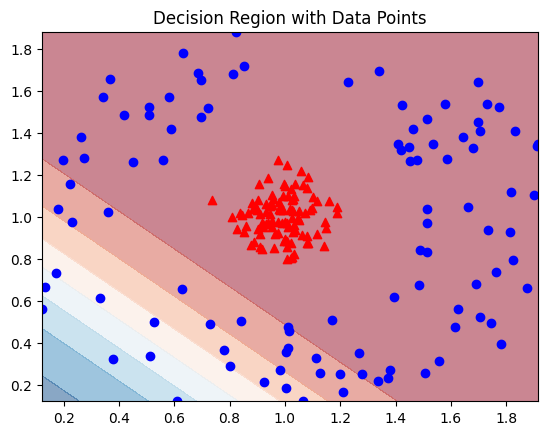

In [98]:
# Correctly stacking the data points
X2 = np.vstack([positive_x, negative_x])
y2 = np.array([1]*positive_x.shape[0] + [0]*negative_x.shape[0])  # Correctly assigning labels to each class
plot_decision_boundary(model.to('cpu'), X2, y2)

## Εκπαιδεύουμε πάλι με τα καινούργια δεδομένα

Δεν περιμέναμε ποτέ να τα πάει καλά το προ-εκπαιδευμένο δίκτυο. Γιατί ένα δίκτυο εκπαιδευμένο με δεδομένα εντελώς άλλης μορφής να τα πάει καλά;

Ας ξαναδοκιμάσουμε, εκπαιδεύοντας με τα καινούργια δεδομένα.

### Καινούργιο Data Loader

Πρέπει να φτιάξουμε καινούργιο Data Loader με τα δεδομένα μας. Θα το ονομάσουμε ``train_loader2``.

In [99]:
# τα δεδομένα (X,y) τα έχουμε δημιουργήσει πιο πάνω
tensor_x_train2 = torch.tensor(X2, dtype=torch.float32) # transform to torch tensor
tensor_y_train2 = torch.tensor(y2, dtype=torch.long)     # labels should be torch.long for classification

m = 32 # Batch size
data_train2 = TensorDataset(tensor_x_train2, tensor_y_train2) # create your dataset
train_loader2 = DataLoader(data_train2, batch_size=m, shuffle=True) # create your dataloader with training data

In [100]:
model = SimpleClassifier()
model.to(device)

SimpleClassifier(
  (fc): Linear(in_features=2, out_features=2, bias=True)
)

In [101]:
optimizer = optim.Adam(model.parameters(), lr=0.1)
epochs = 15 # ας του δώσουμε λίγο παραπάνω χρόνο!

## Δίνουμε την εντολή "```model.fit```"

Epoch 1/15, Training Loss: -0.47750099641936167, Training Accuracy: 0.5000
Epoch 2/15, Training Loss: -0.5055707437651498, Training Accuracy: 0.5000
Epoch 3/15, Training Loss: -0.5088821223803929, Training Accuracy: 0.5000
Epoch 4/15, Training Loss: -0.45949592042182175, Training Accuracy: 0.5000
Epoch 5/15, Training Loss: -0.5085523852280208, Training Accuracy: 0.5000
Epoch 6/15, Training Loss: -0.5188607616083962, Training Accuracy: 0.5000
Epoch 7/15, Training Loss: -0.4987566811697824, Training Accuracy: 0.5200
Epoch 8/15, Training Loss: -0.5269174235207694, Training Accuracy: 0.5750
Epoch 9/15, Training Loss: -0.5638096460274288, Training Accuracy: 0.6100
Epoch 10/15, Training Loss: -0.5641812895025525, Training Accuracy: 0.6400
Epoch 11/15, Training Loss: -0.5971660188266209, Training Accuracy: 0.6700
Epoch 12/15, Training Loss: -0.6239158511161804, Training Accuracy: 0.6650
Epoch 13/15, Training Loss: -0.6173557724271502, Training Accuracy: 0.6800
Epoch 14/15, Training Loss: -0.5

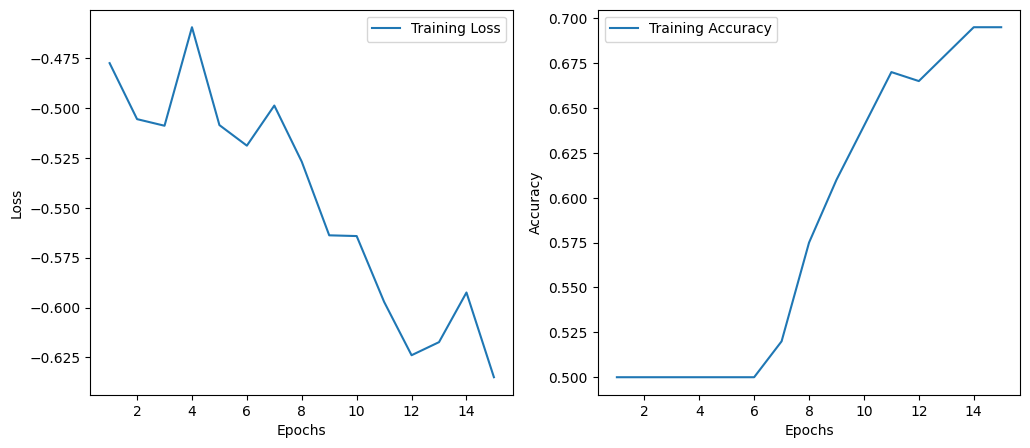

In [102]:
torch.manual_seed(42)
train(model, train_loader2, optimizer, epochs)


## Δεν τα καταφέραμε

Βλέπουμε πως σε αντίθεση με τα πρώτα μας δεδομένα, δεν καταφέραμε να πετύχουμε πάνω από 75% ακρίβεια.

Ας δούμε και τις ισοϋψείς καμπύλες. Όπως και περιμέναμε, είναι γραμμικές -- κάτι που εμφανώς, δεν είναι συμβατό με τα δεδομένα μας.

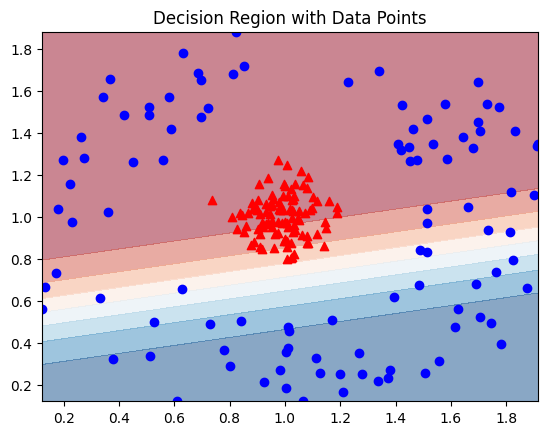

In [103]:
plot_decision_boundary(model.to('cpu'), X2, y2)

### Δεν τα πήγαμε πολύ καλά

Δεν θα έπρεπε να μας κάνει εντύπωση. Όλα τα δίκτυα στην οιγογένεια που έχουμε ορίσει είναι γραμμικά. Δηλαδή, όταν εκπαιδεύουμε, ψάχνουνε όλους τους δυνατούς **γραμμικούς** διαχωρισμούς των δεδομένων για να βρούμε τον καλύτερο.

Όπως μπορούμε να δούμε, δεν υπάρχει κανένας καλός γραμμικός κανόνας που χωρίζει (ταξινομεί) τα δεδομένα στις σωστές κατηγορίες.

# Μη γραμμικά δεδομένα απαιτούν μη γραμμικό δίκτυο

Πρέπει να χτίσουμε πιο βαθύ και μη γραμμικό δίκτυο για να τα πάμε καλύτερα

Στο πρώτο ```def``` τώρα ορίζουμε 3 γραμμικά επίπεδα και το ReLU, που είναι μη-γραμμικό.

Στο δεύτερο ```def``` χρησιμοποιούμε τα 3 επίπεδα που ορίσαμε μαζί με το ReLU, σαν τουβλάκια για να χτίσουμε το νευρωνικό μας δίκτυο:

1. Τα δεδομένα εισόδου ($x$) πρώτα περνάνε από το fc1.
2. Μετά περνάνε από ReLU.
3. Ύστερα από το fc2.
4. Μετά από δεύτερο ReLU.
5. Μετά από το τρίτο γραμμικό επίπεδο fc3.
6. Και τελικά από το ```F.log_softmax``` που μετατρέπει τους δύο τελικούς αριθμούς που παράγει το νευρωνικό μας δίκτυο σε θετικούς αριθμούς που αρθροίζουν σε μονάδα: $(p,1-p)$.


In [104]:

import torch
import torch.nn as nn
import torch.nn.functional as F

class DeeperNet(nn.Module):
    def __init__(self):
        super(DeeperNet, self).__init__()
        self.fc1 = nn.Linear(2, 10)  # First layer, from 2 inputs to 10 outputs
        self.fc2 = nn.Linear(10, 10) # Second layer, 10 to 10
        self.fc3 = nn.Linear(10, 2)  # Output layer, from 10 to 2 outputs
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.relu(x)
        x = self.fc3(x)
        x = F.log_softmax(x, dim=1)  # Applying log_softmax for compatibility with NLLLoss
        return x


In [105]:
# Set the random seed
torch.manual_seed(64)

In [106]:
model = DeeperNet()
model.to(device)


DeeperNet(
  (fc1): Linear(in_features=2, out_features=10, bias=True)
  (fc2): Linear(in_features=10, out_features=10, bias=True)
  (fc3): Linear(in_features=10, out_features=2, bias=True)
  (relu): ReLU()
)

Epoch 1/3, Training Loss: 0.7017263514654977, Training Accuracy: 0.5000
Epoch 2/3, Training Loss: 0.6362122893333435, Training Accuracy: 0.9600
Epoch 3/3, Training Loss: 0.47765396748270306, Training Accuracy: 0.9900
Loaded the best model from epoch 3 with Training Accuracy: 0.9900


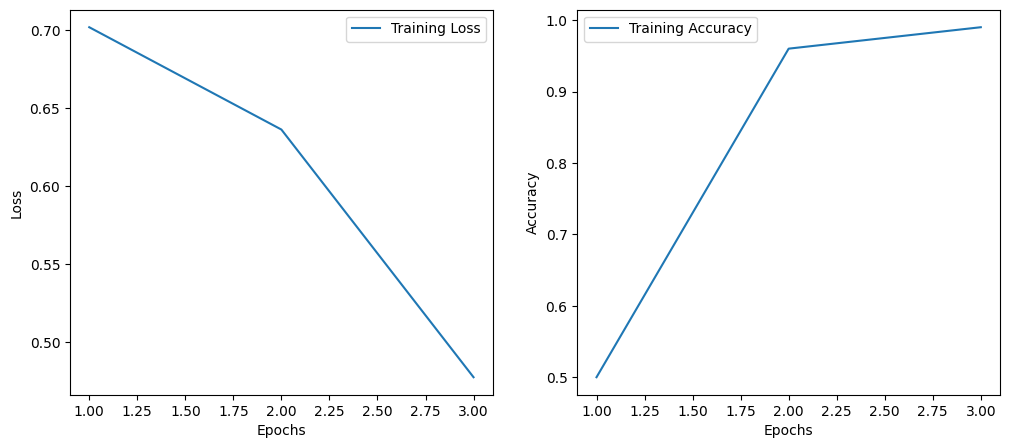

In [107]:
torch.manual_seed(64)
optimizer = optim.Adam(model.parameters(), lr=0.05)
epochs = 3
train(model, train_loader2, optimizer, epochs)


## Ας το τρέξουμε ακόμα λίγα epochs

Epoch 1/10, Training Loss: 0.36900436878204346, Training Accuracy: 0.9350
Epoch 2/10, Training Loss: 0.25080064151968273, Training Accuracy: 0.9900
Epoch 3/10, Training Loss: 0.15917323316846574, Training Accuracy: 0.9850
Epoch 4/10, Training Loss: 0.10156561647142683, Training Accuracy: 1.0000
Epoch 5/10, Training Loss: 0.050919627504689355, Training Accuracy: 1.0000
Epoch 6/10, Training Loss: 0.028441801933305606, Training Accuracy: 0.9950
Epoch 7/10, Training Loss: 0.019507960815514837, Training Accuracy: 1.0000
Epoch 8/10, Training Loss: 0.012148274574428797, Training Accuracy: 1.0000
Epoch 9/10, Training Loss: 0.010022260780845369, Training Accuracy: 1.0000
Epoch 10/10, Training Loss: 0.005368080489071352, Training Accuracy: 1.0000
Loaded the best model from epoch 4 with Training Accuracy: 1.0000


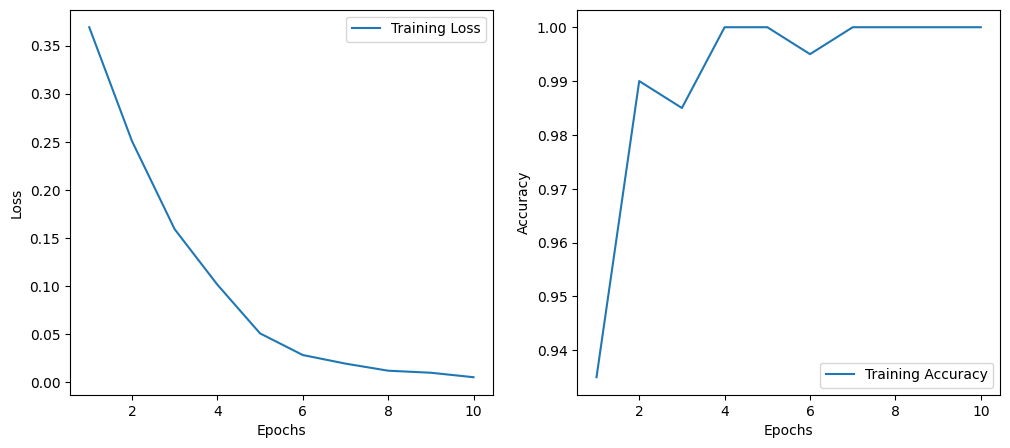

In [108]:
torch.manual_seed(64)
optimizer = optim.Adam(model.parameters(), lr=0.05)
epochs = 10
train(model, train_loader2, optimizer, epochs)


## Τα Καταφέραμε

Βλέπουμε από τα γραφήματα πως το σφάλμα είναι πολύ χαμηλό, και η ακρίβεια πολύ ψυλή.

Τώρα βλέπουμε τις ισοϋψείς καμπύλες. Όπως θα δούμε, είναι μη-γραμμικές και ταιριάζουν με την μορφή των δεδομένων μας.

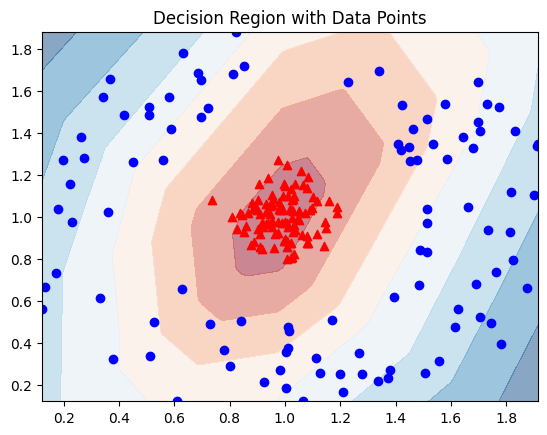

In [109]:
plot_decision_boundary(model.to('cpu'), X2, y2)

# Ακόμα Πιο Βαθύ Δίκτυο

Τώρα εκπαιδεύουμε ένα ακόμα πιο βαθύ δίκτυο, που έχει και πιο πολλούς νευρώνες στα ενδιάμεσα επίπεδα.

Επίσης παρατηρείστε πως αντί για ReLU χρησιμοποιούμε μία άλλη μη-γραμμική συνάρτηση που κανονικοποιεί τα δεδομένα σε κάθε επίπεδο: ``BatchNorm1d`` -- αυτό λέγεται [Batch Normalization](https://pytorch.org/docs/stable/generated/torch.nn.BatchNorm1d.html)

In [110]:
class EnhancedNet(nn.Module):
    def __init__(self):
        super(EnhancedNet, self).__init__()
        self.fc1 = nn.Linear(2, 20)  # Increase width
        self.bn1 = nn.BatchNorm1d(20)  # Batch normalization
        self.fc2 = nn.Linear(20, 40)
        self.bn2 = nn.BatchNorm1d(40)
        self.fc3 = nn.Linear(40, 40)
        self.bn3 = nn.BatchNorm1d(40)
        self.fc4 = nn.Linear(40, 20)
        self.bn4 = nn.BatchNorm1d(20)
        self.fc5 = nn.Linear(20, 2)

    def forward(self, x):
        x = self.fc1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.fc2(x)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.fc3(x)
        x = self.bn3(x)
        x = F.relu(x)
        x = self.fc4(x)
        x = self.bn4(x)
        x = F.relu(x)
        x = self.fc5(x)
        return F.log_softmax(x, dim=1)


In [111]:
# Set the random seed
torch.manual_seed(42)

In [112]:
model = EnhancedNet()
model.to(device)


EnhancedNet(
  (fc1): Linear(in_features=2, out_features=20, bias=True)
  (bn1): BatchNorm1d(20, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=20, out_features=40, bias=True)
  (bn2): BatchNorm1d(40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc3): Linear(in_features=40, out_features=40, bias=True)
  (bn3): BatchNorm1d(40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc4): Linear(in_features=40, out_features=20, bias=True)
  (bn4): BatchNorm1d(20, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc5): Linear(in_features=20, out_features=2, bias=True)
)

In [113]:
optimizer = optim.Adam(model.parameters(), lr=0.05, weight_decay=1e-4)
epochs = 50

Epoch 1/50, Training Loss: 0.2716026343405247, Training Accuracy: 0.4550
Epoch 2/50, Training Loss: 0.24182808389221983, Training Accuracy: 0.9100
Epoch 3/50, Training Loss: 0.07544280947851283, Training Accuracy: 0.9600
Epoch 4/50, Training Loss: 0.06632944981434516, Training Accuracy: 0.9700
Epoch 5/50, Training Loss: 0.015352906958599175, Training Accuracy: 0.9850
Epoch 6/50, Training Loss: 0.025117052918566123, Training Accuracy: 0.9900
Epoch 7/50, Training Loss: 0.1798774439708463, Training Accuracy: 0.9900
Epoch 8/50, Training Loss: 0.11129587236791849, Training Accuracy: 0.7750
Epoch 9/50, Training Loss: 0.11318760498293809, Training Accuracy: 0.9400
Epoch 10/50, Training Loss: 0.23777152890605585, Training Accuracy: 1.0000
Epoch 11/50, Training Loss: 0.19989953775491034, Training Accuracy: 0.9750
Epoch 12/50, Training Loss: 0.0844082704612187, Training Accuracy: 0.9050
Epoch 13/50, Training Loss: 0.12723767278449877, Training Accuracy: 0.9900
Epoch 14/50, Training Loss: 0.06648

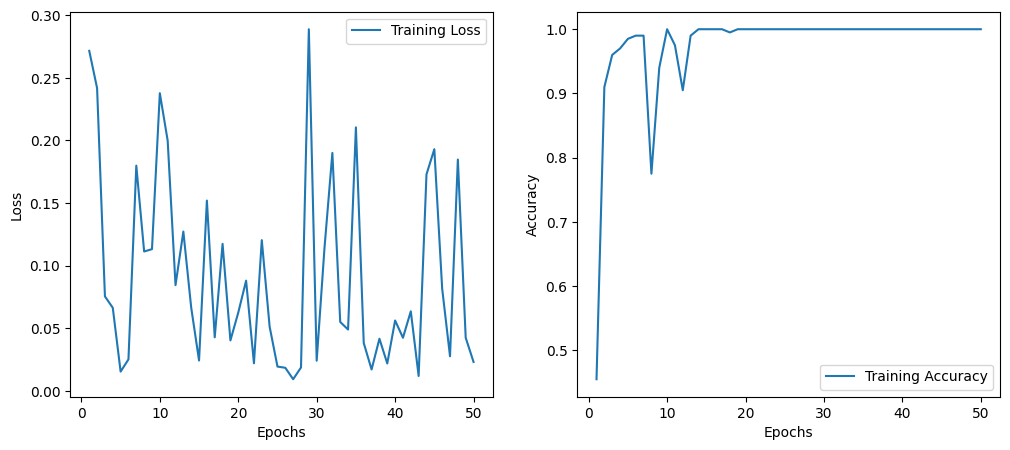

In [114]:
train(model, train_loader2, optimizer, epochs)


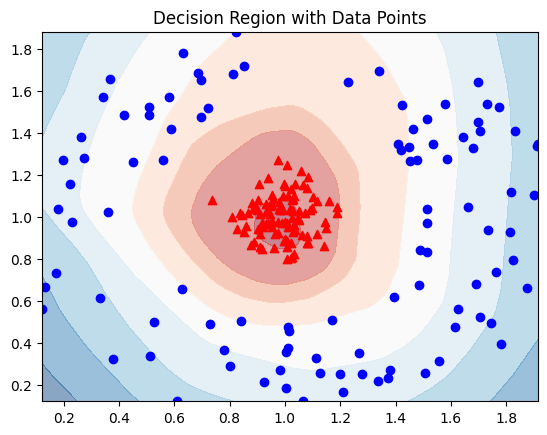

In [115]:
plot_decision_boundary(model.to('cpu'), X2, y2)

# **Model.fit(X,y)**

Στην αρχική μας συζήτηση, είχαμε πει πως τα πράγματα είναι πολύ πιο περίπλοκα για τα νευρωνικά δίκτυα, σε σχέσει με το απλό "model.fit(X,y)". Υπάρχουν πολλοί λόγοι για αυτήν την πολυπλοκότητα. Αναφέρουμε μόνον έναν εδώ: υπάρχουν πάρα πολλες παράμετροι, οπότε η εύρεση καλών τιμών για τις παράμετρους είναι πολύπλοκη διαδικασία.

Ας τους μετρήσουμε:

In [116]:
def count_trainable_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# Example usage
num_params = count_trainable_parameters(model)
print(f"Number of trainable parameters: {num_params}")


Number of trainable parameters: 3642


**Εδώ δίνουμε μια ευκαιρία να εξερευνήσουμε εμπειρικά αυτήν την δυσκολία.**

Το βασικό πρόβλημα είναι πως ιδαίτερα όταν έχουμε πολλές παραμέτρους, όπως και συμβαίνει με πιο βαθιά νευρωνικά δίκτυα, δεν έχουμε την υπολογιστική δύναμη να ψάξουμε κάθε πιθανό συνδιασμό παραμέτρων.

Για αυτό τον λόγο, δίνουμε τις εντολές που έχουμε συζητήσει πιο πάνω.

Έχουμε:
```
optimizer = optim.Adam(model.parameters(), lr=0.05, weight_decay=1e-4)
epochs = 50
```

και κρυμμένο μέσα στην μέθοδο ```train``` έχουμε και τον scheduler:
```
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.1)
```

Αυτές μας λένε πόσο θα ψάξουμε (epochs = 50), και **πώς** θα ψάξουμε για γειτονικές λύσεις που βελτιώνουν το νευρωνικό (``optim.Adam``).

Οι λεπτομέρειες εδώ απαιτούν παραπάνω μαθηματικά απ'ότι θέλουμε προς το παρόν να χρησιμοποιήσουμε. Αλλά μπορούμε εμπειρικά να δούμε πως πραγματικά, το πρόβλημα παρουσιάζει κάποιες δυσκολίες που δεν εμφανίζονται σε πιο μικρά/απλά προβλήματα.

# Ξανατρέχουμε αυτό που κάναμε πιο πάνω

Κάθε φορά που δίνουμε την εντολή
```
model = DeeperNet()
```
το μοντέλο και οι τιμές των παραμέτρων αρχικοποιούνται με άλλες τυχαίες τιμές. Η εύρεση καλύτερων παραμέτρων αρχίζει από αυτό το σημείο, και όπως μπορούμε να δούμε εμπειρικά, δεν καταλήγει πάντα στο ίδιο σημείο.

In [117]:
torch.manual_seed(64)
model = DeeperNet()
model.to(device)

DeeperNet(
  (fc1): Linear(in_features=2, out_features=10, bias=True)
  (fc2): Linear(in_features=10, out_features=10, bias=True)
  (fc3): Linear(in_features=10, out_features=2, bias=True)
  (relu): ReLU()
)

Epoch 1/15, Training Loss: 0.7017263514654977, Training Accuracy: 0.5000
Epoch 2/15, Training Loss: 0.6362122893333435, Training Accuracy: 0.9600
Epoch 3/15, Training Loss: 0.47765396748270306, Training Accuracy: 0.9900
Epoch 4/15, Training Loss: 0.2974875101021358, Training Accuracy: 0.9950
Epoch 5/15, Training Loss: 0.13434614453996932, Training Accuracy: 0.9850
Epoch 6/15, Training Loss: 0.07779758769486632, Training Accuracy: 0.9950
Epoch 7/15, Training Loss: 0.04447790714246886, Training Accuracy: 1.0000
Epoch 8/15, Training Loss: 0.041431140686784475, Training Accuracy: 0.9800
Epoch 9/15, Training Loss: 0.033241668449980874, Training Accuracy: 1.0000
Epoch 10/15, Training Loss: 0.022907954241548265, Training Accuracy: 1.0000
Epoch 11/15, Training Loss: 0.007751492542281214, Training Accuracy: 0.9950
Epoch 12/15, Training Loss: 0.009929909071485912, Training Accuracy: 1.0000
Epoch 13/15, Training Loss: 0.006086068261148674, Training Accuracy: 1.0000
Epoch 14/15, Training Loss: 0.0

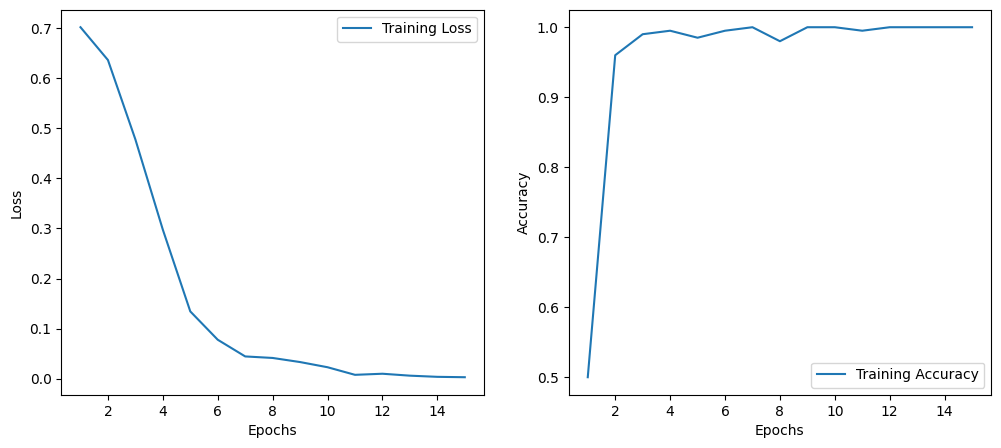

In [118]:
torch.manual_seed(64)
optimizer = optim.Adam(model.parameters(), lr=0.05)
epochs = 15
train(model, train_loader2, optimizer, epochs)


# Τώρα ξανατρέξτε με άλλο random seed

```
torch.manual_seed(42)
```

In [119]:
torch.manual_seed(42)
model = DeeperNet()
model.to(device)

DeeperNet(
  (fc1): Linear(in_features=2, out_features=10, bias=True)
  (fc2): Linear(in_features=10, out_features=10, bias=True)
  (fc3): Linear(in_features=10, out_features=2, bias=True)
  (relu): ReLU()
)

Epoch 1/150, Training Loss: 0.7119825056621006, Training Accuracy: 0.5000
Epoch 2/150, Training Loss: 0.7029742513384137, Training Accuracy: 0.5000
Epoch 3/150, Training Loss: 0.6849819251469204, Training Accuracy: 0.6450
Epoch 4/150, Training Loss: 0.6633208819798061, Training Accuracy: 0.4650
Epoch 5/150, Training Loss: 0.6243732741900853, Training Accuracy: 0.8700
Epoch 6/150, Training Loss: 0.5094229408672878, Training Accuracy: 0.8350
Epoch 7/150, Training Loss: 0.40140046392168316, Training Accuracy: 0.9150
Epoch 8/150, Training Loss: 0.28869917137282236, Training Accuracy: 0.9200
Epoch 9/150, Training Loss: 0.24216944298573903, Training Accuracy: 0.9450
Epoch 10/150, Training Loss: 0.1860541467155729, Training Accuracy: 0.9350
Epoch 11/150, Training Loss: 0.19619384514433996, Training Accuracy: 0.9250
Epoch 12/150, Training Loss: 0.2179131188562938, Training Accuracy: 0.8500
Epoch 13/150, Training Loss: 0.3120745431099619, Training Accuracy: 0.9200
Epoch 14/150, Training Loss: 0

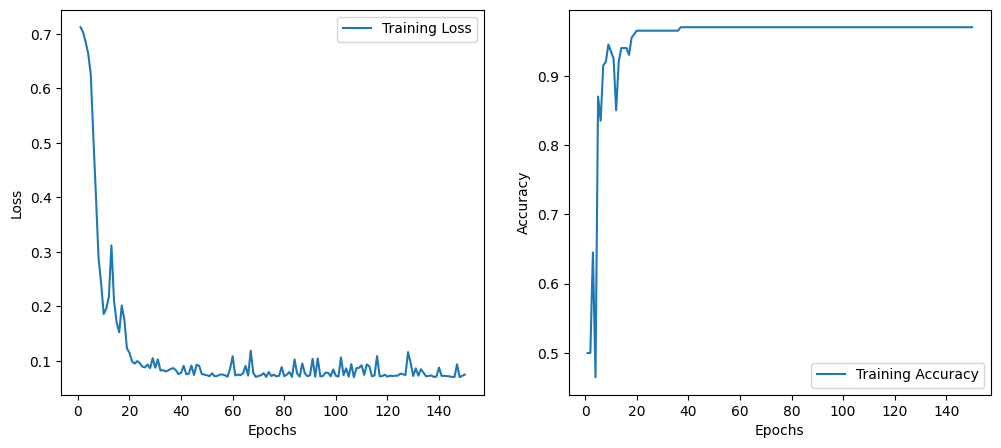

In [120]:
torch.manual_seed(42)
optimizer = optim.Adam(model.parameters(), lr=0.05)
epochs = 150
train(model, train_loader2, optimizer, epochs)

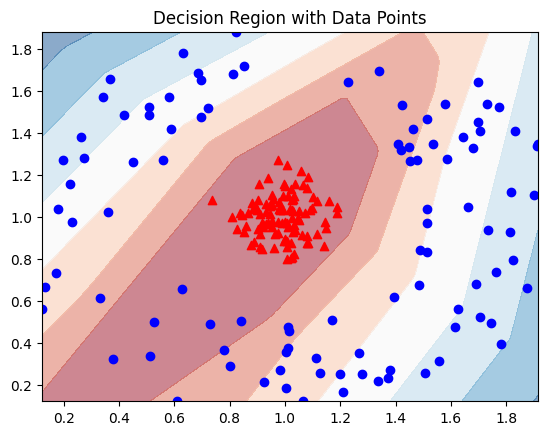

In [121]:
plot_decision_boundary(model.to('cpu'), X2, y2)